## Load strong non-linear surprises SNS-cases data

We stored the cases in the `cases_by_number` folder. Here, we show how to open an plot these cases using `xarray, cartopy, and pandas`.

Each dataset contains a lot of information, the most important columns are:

1.  key -> the unique identifier corresponding to model, ssp, variant-label, variable etc.
2.  Lat, lon, time -> these are the relevant dimensions
3.  `map` -> for each key, where the key occured (as function of lat, lon)
4.  `time_series` -> for each key, how the annual average evolves over time
5.  `case_number` -> the case number as in the paper
6.  `group` -> the categories (A-I) from the paper
7.  `case_type` -> if something is abrupt or gradual
8.  `activity_id, institution_id, source_id, experiment_id, variant_label, variable_id` -> attributes to identify cases / models



Used software:
```
 python   3.8.19
  scipy   1.10.1 
 xarray 2023.1.0
  numpy   1.24.4 
cartopy   0.21.0 
```

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy
import os
import pandas as pd

### Load case by number


In [2]:
ds_case_1 = xr.open_mfdataset("dramatic_sns_cases.nc")
ds_case_1 = ds_case_1.isel(key=np.argwhere(ds_case_1.case_number.values == 1).squeeze())
ds_case_1

<xarray.Dataset>
Dimensions:         (key: 2, lat: 180, lon: 360, time: 651)
Coordinates:
  * key             (key) object 'ScenarioMIP.CSIRO-ARCCSS.ACCESS-CM2.ssp585....
  * lat             (lat) float64 89.24 88.25 87.25 ... -87.25 -88.25 -89.24
  * lon             (lon) float64 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * time            (time) int64 1850 1851 1852 1853 ... 2497 2498 2499 2500
Data variables: (12/15)
    map             (key, lat, lon) bool dask.array<chunksize=(2, 180, 360), meta=np.ndarray>
    time_series     (key, time) float64 dask.array<chunksize=(2, 651), meta=np.ndarray>
    units           (key) object dask.array<chunksize=(2,), meta=np.ndarray>
    cell_area       (lat, lon) float64 dask.array<chunksize=(180, 360), meta=np.ndarray>
    activity_id     (key) object dask.array<chunksize=(2,), meta=np.ndarray>
    institution_id  (key) object dask.array<chunksize=(2,), meta=np.ndarray>
    ...              ...
    variable_id     (key) object dask.array<chunksize=(2,), meta=np.ndarray>
    case_type       (key) object dask.array<chunksize=(2,), meta=np.ndarray>
    shift_type      (key) object dask.array<chunksize=(2,), meta=np.ndarray>
    group           (key) object dask.array<chunksize=(2,), meta=np.ndarray>
    case_number     (key) int64 dask.array<chunksize=(2,), meta=np.ndarray>
    sns_criterion   (key) object dask.array<chunksize=(2,), meta=np.ndarray>

Case 0 is associated to two time series: "siconc and sos"


In [3]:
ds_case_1.key.values

array(['ScenarioMIP.CSIRO-ARCCSS.ACCESS-CM2.ssp585.r1i1p1f1.siconc.0000',
       'ScenarioMIP.CSIRO-ARCCSS.ACCESS-CM2.ssp585.r1i1p1f1.sos.0000'],
      dtype=object)

Let's have a look at the time series and at the positions of both keys


==========ScenarioMIP.CSIRO-ARCCSS.ACCESS-CM2.ssp585.r1i1p1f1.siconc.0000==========


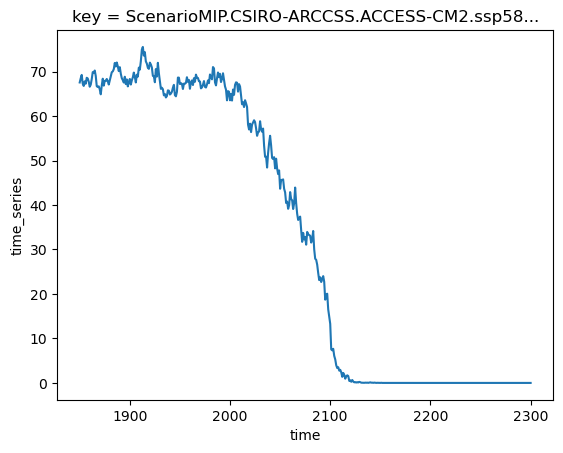

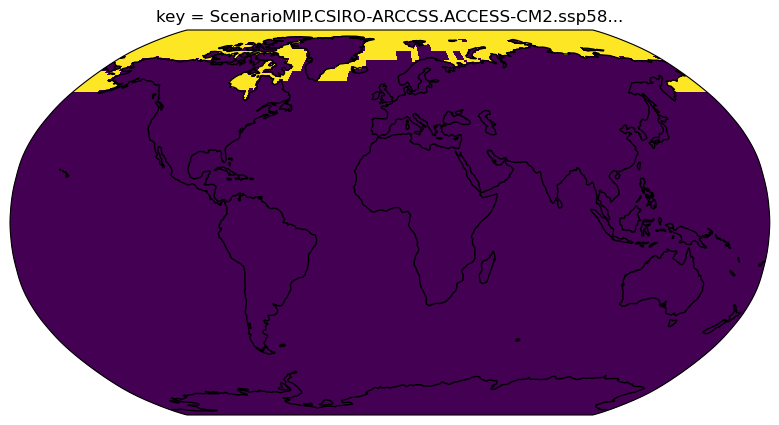

==========ScenarioMIP.CSIRO-ARCCSS.ACCESS-CM2.ssp585.r1i1p1f1.sos.0000==========


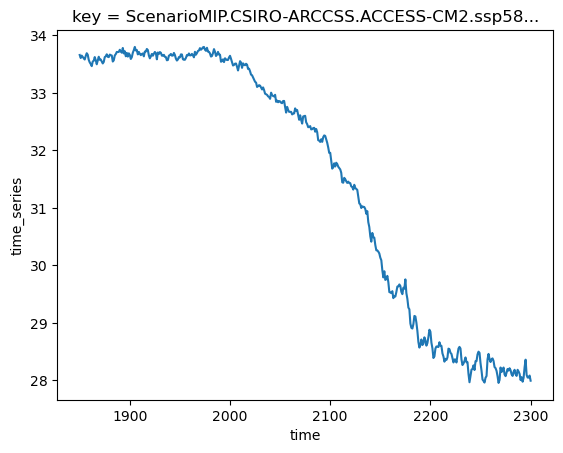

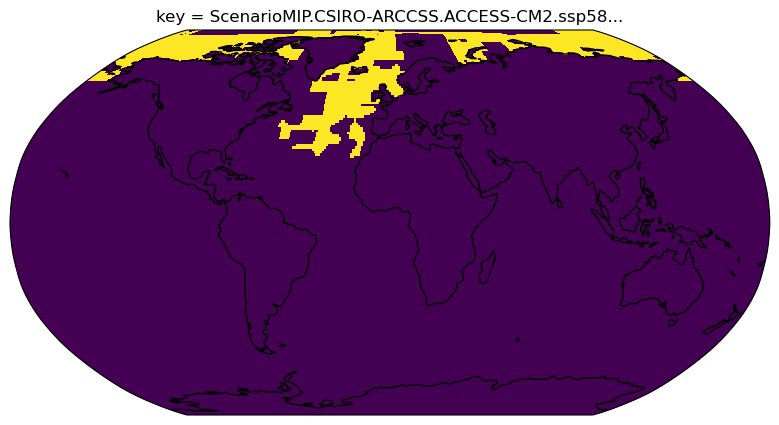

In [4]:
for key, ds_sel in ds_case_1.groupby("key"):
    print("=" * 10 + key + "=" * 10)
    ds_sel["time_series"].plot()
    plt.show()
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1, projection=cartopy.crs.Robinson())
    ax.coastlines()
    ds_sel["map"].plot(transform=cartopy.crs.PlateCarree(), add_colorbar=False)
    plt.show()

## Combining cases

Let's read all the cases and combine them in one big xr.Dataset


In [5]:
ds_complete = xr.open_mfdataset("dramatic_sns_cases.nc")

First, let's make a big table with all models, categories, SSPs, variables and variant-labels for each case


In [6]:
pd.options.display.max_rows = len(ds_complete.key) + 1

In [7]:
pd.DataFrame(
    {
        k: ds_complete[k].values
        for k in "case_number group source_id experiment_id variable_id variant_label sns_criterion".split()
    }
).sort_values("case_number")

,case_number,group,source_id,experiment_id,variable_id,variant_label,sns_criterion
194,1,A,ACCESS-CM2,ssp585,sos,r1i1p1f1,St4
142,1,A,ACCESS-CM2,ssp585,siconc,r1i1p1f1,St1
136,2,A,ACCESS-ESM1-5,ssp585,siconc,r4i1p1f1,St1
132,2,A,ACCESS-ESM1-5,ssp585,siconc,r10i1p1f1,St1
133,2,A,ACCESS-ESM1-5,ssp585,siconc,r1i1p1f1,St1
134,2,A,ACCESS-ESM1-5,ssp585,siconc,r2i1p1f1,St1
135,2,A,ACCESS-ESM1-5,ssp585,siconc,r3i1p1f1,St1
137,2,A,ACCESS-ESM1-5,ssp585,siconc,r5i1p1f1,St1
138,2,A,ACCESS-ESM1-5,ssp585,siconc,r6i1p1f1,St1
140,2,A,ACCESS-ESM1-5,ssp585,siconc,r8i1p1f1,St1


As an example, let's plot all the cat. A siconc cases in `r1i1p1f1` variants


In [8]:
is_r1i1p1f1 = ds_complete["variant_label"] == "r1i1p1f1"
is_cat_big_a = ds_complete["group"] == "A"
is_siconc = ds_complete["variable_id"] == "siconc"
is_siconc |= ds_complete["variable_id"] == "siconca"

ds_cat_a_r1i1p1f1 = ds_complete.isel(
    key=np.argwhere(
        is_cat_big_a.values & is_cat_big_a.values & is_siconc.values
    ).squeeze()
)

Text(0.5, 0, 'Time [year]')

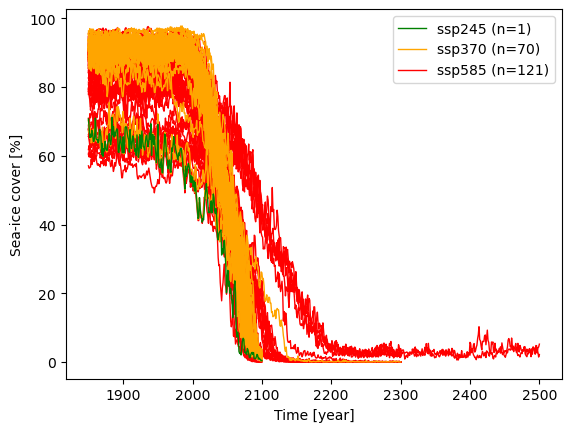

In [9]:
for ssp, ds_sub in ds_cat_a_r1i1p1f1.groupby("experiment_id"):
    kw = dict(
        color=dict(ssp245="green", ssp370="orange", ssp585="red")[ssp],
        zorder=-int(ssp[3]),
        lw=1,
    )
    # Plot the first time series to add a label
    plt.plot(
        ds_sub["time"],
        ds_sub["time_series"].values[0],
        label=f"{ssp} (n={len(ds_sub.key)})",
        **kw,
    )
    for ts in ds_sub["time_series"].values[1:]:
        # Plot the rest
        plt.plot(ds_sub["time"], ts, **kw)
plt.legend()
plt.ylabel("Sea-ice cover [%]")
plt.xlabel("Time [year]")

## Showing the heatmap of where group `B` occurs (unweighted)

Now, let's do something naive and plot what fraction of ensemble members in category `B` in each location.


In [10]:
ds_group_B = ds_complete.isel(
    key=np.argwhere((ds_complete["group"] == "B").values).squeeze()
)

In [11]:
map_of_b = ds_group_B["map"].sum(dim="key").load()

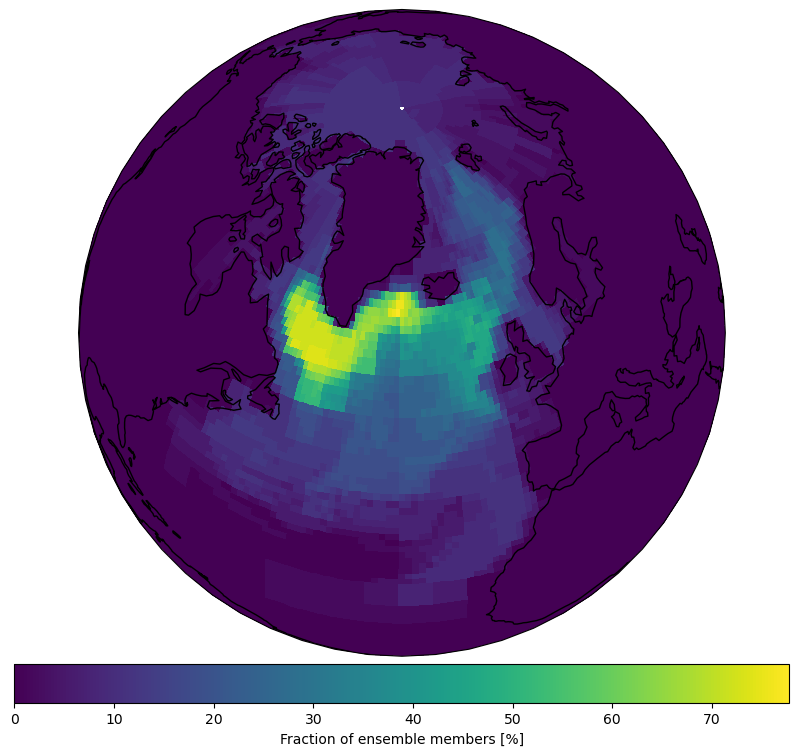

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(
    1,
    1,
    1,
    projection=cartopy.crs.NearsidePerspective(
        satellite_height=1e7, central_latitude=60, central_longitude=-30
    ),
)
ax.coastlines()
heat_map_percent = 100 * map_of_b / len(ds_group_B["key"])
heat_map_percent.plot(
    transform=cartopy.crs.PlateCarree(),
    add_colorbar=True,
    cbar_kwargs=dict(
        orientation="horizontal", pad=0.01, label="Fraction of ensemble members [%]"
    ),
)
plt.show()

Of course, this is a bit crude. Depending on what you want to do, you have to also correct for the number of variables, the number of ensemble members, the number of SSPs per case, you have to do some appropriate weighting.
